In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010022restnew 20150724 14.csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020027rest 20150713 1049..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010008_rest 20150619 1653.csv
/kaggle/input/preprocessed-raw-m

# **SETUP SAVE AND SPLITS**

In [2]:
# ================================================================================================
# CELL 1 — MODMA EEG Dataset: Setup + Load + Preprocess + Subject-Wise Split + Save
# ================================================================================================
#
# CRITICAL METHODOLOGICAL CORRECTIONS IMPLEMENTED:
# ------------------------------------------------
# 1. SUBJECT-WISE SPLITTING: All epochs/samples from each subject remain exclusively in either
# train OR test set — never split across both. This prevents data leakage where models learn
# subject-specific EEG "fingerprints" rather than depression biomarkers.
# Reference: Brookshire et al. (2024) "Data leakage in deep learning studies of translational EEG"
#
# 2. CORRECT NORMALIZATION ORDER: StandardScaler is fit ONLY on training data, then applied
# (transform only) to test data. Computing statistics on full dataset before splitting
# leaks test information into training preprocessing.
# Reference: scikit-learn documentation "Common pitfalls and recommended practices"
#
# 3. TEMPORAL STRUCTURE PRESERVATION: For TCN/CNN architectures, the sequential ordering of
# timepoints within epochs is preserved. No shuffling of samples within recording segments.
#
# 4. SUBJECT ID EXTRACTION: MODMA filenames encode subject identity and diagnosis:
# - "0201_XXX" prefix → MDD patient (Major Depressive Disorder)
# - "0203_XXX" prefix → HC subject (Healthy Control)
# This is used for both label verification and subject-wise partitioning.
#
# DATASET: MODMA (Multi-modal Open Dataset for Mental-disorder Analysis)
# - 128-channel EGI HydroCel Geodesic Sensor Net
# - 250 Hz sampling rate
# - 5-minute eyes-closed resting-state recordings
# - 24 MDD patients, 29 healthy controls (N=53)
# - Reference: Cai et al. (2022) Scientific Data, DOI: 10.1038/s41597-022-01211-x
#
# ================================================================================================
import os
import re
import json
import warnings
from collections import defaultdict
from typing import Tuple, Dict, List, Optional
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import tensorflow as tf
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
# ================================================================================================
# CONFIGURATION — EDIT THESE PATHS FOR YOUR SYSTEM
# ================================================================================================
# Windows example: DATA_DIR = r"C:\Users\YourName\Documents\EEG_Data\csv_files"
# Windows example: OUTPUT_DIR = r"C:\Users\YourName\Documents\EEG_Results"
DATA_DIR = "/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2"
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ================================================================================================
# HYPERPARAMETERS
# ================================================================================================
SAMPLE_FRAC = 1.0 # Set to 0.1 for quick debugging; 1.0 for full dataset
TEST_SIZE = 0.2 # Fraction of SUBJECTS (not samples) held out for testing
SEED = 42 # Random seed for reproducibility
VALIDATE_NO_LEAKAGE = True # Programmatically verify zero subject overlap between train/test
# PCA Configuration — DISABLED by default to preserve spatial EEG channel structure
# TCN and CNN architectures exploit spatial relationships between electrodes;
# PCA destroys this topological information by creating linear combinations of channels.
USE_IPCA = False # Set True only for traditional ML (SVM, RF) with feature vectors
IPCA_COMPONENTS = 128 # Ignored when USE_IPCA=False
IPCA_BATCH = 5000
# Temporal Windowing Parameters
WINDOW_SIZE = 250 # 1 second at 250 Hz sampling rate
STRIDE = 125 # 50% overlap for smoother transitions
# Set random seeds for reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)
# ================================================================================================
# GPU CONFIGURATION (Optional — works on Windows with CUDA installed)
# ================================================================================================
gpus = tf.config.experimental.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
        print(f"✓ GPU memory growth enabled: {g}")
    except Exception as e:
        print(f"✗ GPU config failed: {e}")
if not gpus:
    print("ℹ No GPU detected — running on CPU (this is fine for preprocessing)")
# ================================================================================================
# HELPER FUNCTIONS
# ================================================================================================
def extract_subject_id_and_label(filename: str) -> Tuple[Optional[str], Optional[int]]:
    """
    Extract subject ID and diagnostic label from MODMA filename convention.
  
    MODMA Naming Convention:
    ------------------------
    - "0201_XXX.csv" → MDD patient (label = 1)
    - "0203_XXX.csv" → Healthy Control (label = 0)
  
    The subject ID is the full prefix before any additional identifiers,
    ensuring all epochs from one recording session stay together.
  
    Parameters:
        filename: CSV filename (e.g., "0201_001_epoch1.csv")
  
    Returns:
        (subject_id, label) tuple, or (None, None) if pattern doesn't match
    """
    basename = os.path.splitext(filename)[0]
  
    # Pattern 1: Standard MODMA format "0201_XXX" or "0203_XXX"
    # The first 4 digits encode the diagnostic group
    match = re.match(r'^(020[13])[-_]?(\d+)', basename)
    if match:
        group_code = match.group(1)
        subject_num = match.group(2)
        subject_id = f"{group_code}_{subject_num}"
        label = 1 if group_code == "0201" else 0 # MDD=1, HC=0
        return subject_id, label
  
    # Pattern 2: Alternative format with explicit condition markers
    # e.g., "MDD_subj01" or "HC_subj01"
    match = re.match(r'^(MDD|HC)[-_]?(.+)', basename, re.IGNORECASE)
    if match:
        condition = match.group(1).upper()
        subject_num = match.group(2)
        subject_id = f"{condition}_{subject_num}"
        label = 1 if condition == "MDD" else 0
        return subject_id, label
  
    # Pattern 3: Fallback — use entire filename as subject ID, label unknown
    # This triggers a warning and requires manual label assignment
    return basename, None
def detect_eeg_columns(columns: List[str]) -> List[str]:
    """
    Detect EEG electrode columns from DataFrame column names.
  
    Supports common naming conventions:
    - E1, E2, ..., E128 (EGI format)
    - EEG1, EEG2, ..., EEG128
    - EEG_1, EEG_2, etc.
  
    Returns columns sorted by electrode number to preserve spatial ordering.
    """
    regex = re.compile(r'^(?:EEG[_\-\s]?|E[_\-\s]?)(0*)(\d{1,3})$', flags=re.IGNORECASE)
    found = {}
  
    for col in columns:
        match = regex.match(col.strip())
        if match:
            electrode_num = int(match.group(2))
            if 1 <= electrode_num <= 128:
                found[electrode_num] = col
  
    if found:
        # Return columns sorted by electrode number (preserves spatial topology)
        return [found[i] for i in sorted(found.keys())]
  
    # Fallback: any column starting with E or EEG followed by digits
    fallback = [c for c in columns if re.match(r'^(E|EEG)\d+', c, flags=re.IGNORECASE)]
    if fallback:
        return fallback
  
    return []
def verify_no_subject_leakage(train_subjects: set, test_subjects: set) -> bool:
    """
    CRITICAL VALIDATION: Verify zero overlap between training and test subjects.
  
    This check prevents the most common methodological error in EEG classification
    literature, which inflates accuracy by 20-50 percentage points.
  
    Raises AssertionError if any subject appears in both sets.
    """
    overlap = train_subjects & test_subjects
    if overlap:
        raise AssertionError(
            f"DATA LEAKAGE DETECTED! {len(overlap)} subject(s) appear in both train and test sets: "
            f"{overlap}. This invalidates all classification results."
        )
    return True
def subject_wise_train_test_split(
    X: np.ndarray,
    y: np.ndarray,
    subject_ids: np.ndarray,
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Split data ensuring ALL samples from each subject remain in either train OR test set.
  
    This is the methodologically correct approach for EEG-based diagnostic classification.
    Standard train_test_split operates on samples, which causes severe data leakage when
    multiple samples come from the same subject (as in epoched EEG data).
  
    Parameters:
        X: Feature matrix, shape (n_samples, n_features) or (n_samples, n_channels, n_timepoints)
        y: Labels, shape (n_samples,)
        subject_ids: Subject identifier for each sample, shape (n_samples,)
        test_size: Fraction of SUBJECTS to hold out (not fraction of samples)
        random_state: Random seed for reproducibility
  
    Returns:
        X_train, X_test, y_train, y_test, subjects_train, subjects_test
    """
    unique_subjects = np.unique(subject_ids)
    subject_labels = []
  
    # Get the label for each subject (should be consistent across all their samples)
    for subj in unique_subjects:
        subj_mask = subject_ids == subj
        subj_label = y[subj_mask][0] # Take first label (all should be identical)
      
        # Verify label consistency within subject
        if not np.all(y[subj_mask] == subj_label):
            warnings.warn(f"Subject {subj} has inconsistent labels across samples!")
      
        subject_labels.append(subj_label)
  
    subject_labels = np.array(subject_labels)
  
    # Split at the SUBJECT level with stratification by diagnosis
    subjects_train, subjects_test = train_test_split(
        unique_subjects,
        test_size=test_size,
        stratify=subject_labels,
        random_state=random_state
    )
  
    # Create masks for samples belonging to train/test subjects
    train_mask = np.isin(subject_ids, subjects_train)
    test_mask = np.isin(subject_ids, subjects_test)
  
    X_train = X[train_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_test = y[test_mask]
    subj_train = subject_ids[train_mask]
    subj_test = subject_ids[test_mask]
  
    return X_train, X_test, y_train, y_test, subj_train, subj_test
# ================================================================================================
# STEP 1: LOAD CSV FILES AND EXTRACT SUBJECT INFORMATION
# ================================================================================================
print("=" * 80)
print("STEP 1: Loading CSV files and extracting subject information")
print("=" * 80)
csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith('.csv')])
if len(csv_files) == 0:
    raise RuntimeError(f"No CSV files found in DATA_DIR: {DATA_DIR}")
print(f"Found {len(csv_files)} CSV files in {DATA_DIR}\n")
# Data structures to collect samples organized by subject
subject_data = defaultdict(list) # subject_id -> list of DataFrames
subject_labels = {} # subject_id -> diagnostic label
label_source = {} # subject_id -> "filename" or "column"
# Track potential issues
files_without_subject_id = []
label_conflicts = []
for filename in csv_files:
    filepath = os.path.join(DATA_DIR, filename)
  
    # Extract subject ID and label from filename
    subject_id, filename_label = extract_subject_id_and_label(filename)
  
    if subject_id is None:
        files_without_subject_id.append(filename)
        continue
  
    # Read CSV file
    df = pd.read_csv(filepath, engine='python')
  
    # Apply sampling if requested (for debugging)
    if SAMPLE_FRAC is not None and 0 < SAMPLE_FRAC < 1.0:
        df = df.sample(frac=SAMPLE_FRAC, random_state=SEED)
  
    # Try to get label from column if filename didn't provide it
    column_label = None
    for label_col in ['epoch', 'label', 'condition', 'cond', 'target']:
        if label_col in df.columns:
            unique_vals = df[label_col].dropna().unique()
            if len(unique_vals) == 1:
                val = unique_vals[0]
                if isinstance(val, (int, float)):
                    column_label = int(val) if val in [0, 1] else (0 if val == 1 else 1)
                elif str(val).upper() in ['MDD', 'DEPRESSED', 'PATIENT', '1']:
                    column_label = 1
                elif str(val).upper() in ['HC', 'HEALTHY', 'CONTROL', '0']:
                    column_label = 0
            break
  
    # Determine final label (filename takes precedence)
    final_label = filename_label if filename_label is not None else column_label
  
    if final_label is None:
        warnings.warn(f"Cannot determine label for {filename}. Skipping.")
        continue
  
    # Check for label conflicts
    if subject_id in subject_labels:
        if subject_labels[subject_id] != final_label:
            label_conflicts.append((subject_id, subject_labels[subject_id], final_label, filename))
    else:
        subject_labels[subject_id] = final_label
        label_source[subject_id] = "filename" if filename_label is not None else "column"
  
    # Store data
    df['__subject_id'] = subject_id
    df['__source_file'] = filename
    subject_data[subject_id].append(df)
# Report any issues
if files_without_subject_id:
    print(f"⚠ Warning: {len(files_without_subject_id)} files could not be parsed for subject ID")
  
if label_conflicts:
    print(f"⚠ Warning: {len(label_conflicts)} label conflicts detected:")
    for conflict in label_conflicts[:5]:
        print(f" Subject {conflict[0]}: existing={conflict[1]}, new={conflict[2]}, file={conflict[3]}")
# Combine all data
all_dfs = []
for subject_id, df_list in subject_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
    combined_df['__label'] = subject_labels[subject_id]
    all_dfs.append(combined_df)
if not all_dfs:
    raise RuntimeError("No valid data loaded. Check file naming conventions.")
combined = pd.concat(all_dfs, ignore_index=True)
# Print subject statistics
n_subjects = len(subject_labels)
n_mdd = sum(1 for v in subject_labels.values() if v == 1)
n_hc = sum(1 for v in subject_labels.values() if v == 0)
print(f"\n✓ Successfully loaded data from {n_subjects} subjects")
print(f" - MDD patients (label=1): {n_mdd}")
print(f" - Healthy controls (label=0): {n_hc}")
print(f" - Total samples: {len(combined):,}")
print(f" - Samples per subject (avg): {len(combined) / n_subjects:.1f}")
# ================================================================================================
# STEP 2: DETECT AND VALIDATE EEG COLUMNS
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 2: Detecting EEG electrode columns")
print("=" * 80)
eeg_cols = detect_eeg_columns(combined.columns)
if not eeg_cols:
    raise RuntimeError(
        "No EEG columns detected. Expected columns like E1-E128 or EEG1-EEG128. "
        f"Found columns: {list(combined.columns)[:20]}..."
    )
print(f"✓ Detected {len(eeg_cols)} EEG electrode columns")
print(f" First 5: {eeg_cols[:5]}")
print(f" Last 5: {eeg_cols[-5:]}")
# Columns to exclude from features
metadata_cols = {'time', 'condition', 'label', 'epoch', 'target', 'cond',
                 '__source_file', '__label', '__subject_id'}
feature_cols = [c for c in eeg_cols if c.lower() not in {m.lower() for m in metadata_cols}]
if len(feature_cols) == 0:
    raise RuntimeError("No feature columns remaining after filtering metadata.")
print(f"✓ Using {len(feature_cols)} channels as features")
# ================================================================================================
# STEP 3: PREPARE FEATURE MATRIX AND LABELS WITH TEMPORAL WINDOWING
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 3: Preparing feature matrix and labels with temporal windowing")
print("=" * 80)
# Window per subject to avoid mixing
all_windows = []
all_y = []
all_subject_ids = []
for subject_id, df_list in subject_data.items():
    combined_df = pd.concat(df_list, ignore_index=True)
   
    # Extract data for windowing
    X_subject = combined_df[feature_cols].to_numpy(dtype=np.float32) # (timepoints, channels)
   
    # Apply windowing
    num_windows = max(0, (X_subject.shape[0] - WINDOW_SIZE) // STRIDE + 1)
    if num_windows > 0:
        windows = np.array([X_subject[i:i + WINDOW_SIZE] for i in range(0, X_subject.shape[0] - WINDOW_SIZE + 1, STRIDE)])
        all_windows.append(windows)
        all_y.extend([subject_labels[subject_id]] * num_windows)
        all_subject_ids.extend([subject_id] * num_windows)
if all_windows:
    X_full = np.concatenate(all_windows, axis=0) # (n_windows, window_size, channels)
    y = np.array(all_y, dtype=np.int32)
    subject_ids = np.array(all_subject_ids)
    print(f"✓ Windowed feature matrix shape: {X_full.shape}")
    print(f" - {X_full.shape[0]:,} windows")
    print(f" - Window size: {X_full.shape[1]} timepoints x {X_full.shape[2]} channels")
else:
    raise RuntimeError("No valid windows generated. Check data length and window parameters.")
# ================================================================================================
# STEP 4: HANDLE MISSING VALUES
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 4: Handling missing values")
print("=" * 80)
nan_count = np.isnan(X_full).sum()
if nan_count > 0:
    nan_percentage = 100 * nan_count / X_full.size
    print(f"⚠ Found {nan_count:,} NaN values ({nan_percentage:.4f}% of data)")
  
    # Impute with column means (computed per channel, across all windows and timepoints)
    X_reshaped = X_full.reshape(-1, X_full.shape[2]) # (n_windows * window_size, channels)
    col_means = np.nanmean(X_reshaped, axis=0)
    nan_indices = np.where(np.isnan(X_reshaped))
    X_reshaped[nan_indices] = np.take(col_means, nan_indices[1])
    X_full = X_reshaped.reshape(X_full.shape) # Back to original shape
  
    print(f"✓ Imputed NaN values with per-channel means")
else:
    print("✓ No missing values detected")
# ================================================================================================
# STEP 5: OPTIONAL PCA (DISABLED BY DEFAULT)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 5: Dimensionality reduction (PCA)")
print("=" * 80)
if USE_IPCA and IPCA_COMPONENTS is not None and 0 < IPCA_COMPONENTS < X_full.shape[2]:
    from sklearn.decomposition import IncrementalPCA
  
    print(f"Running IncrementalPCA: {X_full.shape[2]} → {IPCA_COMPONENTS} components")
    print("⚠ WARNING: PCA destroys spatial electrode topology. Use only for traditional ML.")
  
    ipca = IncrementalPCA(n_components=IPCA_COMPONENTS)
  
    # Fit incrementally to handle large datasets
    X_reshaped = X_full.reshape(-1, X_full.shape[2]) # Flatten time for PCA on channels
    n_samples = X_reshaped.shape[0]
    for i in range(0, n_samples, IPCA_BATCH):
        ipca.partial_fit(X_reshaped[i:i + IPCA_BATCH])
  
    # Transform in batches
    X_reduced = np.empty((n_samples, IPCA_COMPONENTS), dtype=np.float32)
    for i in range(0, n_samples, IPCA_BATCH):
        X_reduced[i:i + IPCA_BATCH] = ipca.transform(X_reshaped[i:i + IPCA_BATCH]).astype(np.float32)
  
    X_reduced = X_reduced.reshape(X_full.shape[0], X_full.shape[1], IPCA_COMPONENTS) # Back to window shape
  
    X = X_reduced
    explained_var = sum(ipca.explained_variance_ratio_) * 100
    print(f"✓ PCA complete. Explained variance: {explained_var:.1f}%")
    print(f"✓ Reduced shape: {X.shape}")
else:
    X = X_full
    print("✓ PCA SKIPPED — preserving raw EEG channel structure")
    print(f" This is CORRECT for TCN/CNN architectures that exploit spatial relationships")
    print(f" between electrodes. Shape: {X.shape}")
# ================================================================================================
# STEP 6: SUBJECT-WISE TRAIN-TEST SPLIT (CRITICAL FOR VALIDITY)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 6: Subject-wise train-test split (CRITICAL)")
print("=" * 80)
print(f"Splitting {n_subjects} subjects with {TEST_SIZE:.0%} held out for testing...")
print("⚠ Using SUBJECT-WISE splitting to prevent data leakage")
print(" All epochs from each subject will be in EITHER train OR test, never both.\n")
X_train, X_test, y_train, y_test, subjects_train, subjects_test = subject_wise_train_test_split(
    X, y, subject_ids,
    test_size=TEST_SIZE,
    random_state=SEED
)
# Get unique subjects in each split
train_subject_set = set(np.unique(subjects_train))
test_subject_set = set(np.unique(subjects_test))
print(f"Training set:")
print(f" - Subjects: {len(train_subject_set)}")
print(f" - Samples: {X_train.shape[0]:,}")
print(f" - MDD: {np.sum(y_train == 1):,} samples, HC: {np.sum(y_train == 0):,} samples")
print(f"\nTest set:")
print(f" - Subjects: {len(test_subject_set)}")
print(f" - Samples: {X_test.shape[0]:,}")
print(f" - MDD: {np.sum(y_test == 1):,} samples, HC: {np.sum(y_test == 0):,} samples")
# ================================================================================================
# STEP 7: VALIDATE NO DATA LEAKAGE (CRITICAL CHECK)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 7: Validating no subject overlap (data leakage check)")
print("=" * 80)
if VALIDATE_NO_LEAKAGE:
    try:
        verify_no_subject_leakage(train_subject_set, test_subject_set)
        print("✓ VALIDATION PASSED: Zero subject overlap between train and test sets")
        print(" Your results will not be inflated by data leakage.")
    except AssertionError as e:
        print(f"✗ CRITICAL ERROR: {e}")
        raise
else:
    print("⚠ Leakage validation skipped (VALIDATE_NO_LEAKAGE=False)")
# ================================================================================================
# STEP 8: NORMALIZE USING TRAINING DATA ONLY (CORRECT ORDER)
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 8: Standardization (fit on TRAINING data only)")
print("=" * 80)
print("Computing mean and std from TRAINING set only...")
print("⚠ This is the correct order: split FIRST, then normalize")
print(" Fitting on full data before splitting causes statistical leakage.\n")
scaler = StandardScaler()
# Reshape for scaling (flatten time and windows)
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])
# Fit on train
X_train_scaled_reshaped = scaler.fit_transform(X_train_reshaped).astype(np.float32)
# Transform test
X_test_scaled_reshaped = scaler.transform(X_test_reshaped).astype(np.float32)
# Reshape back
X_train_scaled = X_train_scaled_reshaped.reshape(X_train.shape)
X_test_scaled = X_test_scaled_reshaped.reshape(X_test.shape)
print(f"✓ Training set: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}")
print(f"✓ Test set: mean={X_test_scaled.mean():.6f}, std={X_test_scaled.std():.6f}")
print(" (Test set statistics may differ slightly — this is expected and correct)")
# ================================================================================================
# STEP 9: SAVE PROCESSED DATA
# ================================================================================================
print("\n" + "=" * 80)
print("STEP 9: Saving processed data splits")
print("=" * 80)
# Save as compressed numpy archive
npz_path = os.path.join(OUTPUT_DIR, 'data_split.npz')
np.savez_compressed(
    npz_path,
    X_train=X_train_scaled,
    X_test=X_test_scaled,
    y_train=y_train,
    y_test=y_test,
    subjects_train=subjects_train, # NEW: Include subject IDs for later analysis
    subjects_test=subjects_test,
    feature_columns=np.array(feature_cols),
    scaler_mean=scaler.mean_,
    scaler_scale=scaler.scale_
)
print(f"✓ Saved data_split.npz to {OUTPUT_DIR}")
print(f" Contains: X_train, X_test, y_train, y_test, subject IDs, scaler parameters")
# Save metadata and configuration as JSON
metadata = {
    "dataset": "MODMA",
    "task": "MDD_vs_HC_binary_classification",
    "preprocessing": {
        "average_referencing": True,
        "noise_removal": True,
        "bandpass_filtering": True,
        "pca_applied": USE_IPCA,
        "pca_components": IPCA_COMPONENTS if USE_IPCA else None,
        "window_size": WINDOW_SIZE,
        "stride": STRIDE
    },
    "splitting": {
        "method": "subject_wise_stratified",
        "test_size": TEST_SIZE,
        "random_seed": SEED,
        "data_leakage_validated": VALIDATE_NO_LEAKAGE
    },
    "subjects": {
        "total": n_subjects,
        "mdd_count": n_mdd,
        "hc_count": n_hc,
        "train_subjects": sorted(list(train_subject_set)),
        "test_subjects": sorted(list(test_subject_set))
    },
    "samples": {
        "total": int(X.shape[0]),
        "train": int(X_train.shape[0]),
        "test": int(X_test.shape[0]),
        "train_mdd": int(np.sum(y_train == 1)),
        "train_hc": int(np.sum(y_train == 0)),
        "test_mdd": int(np.sum(y_test == 1)),
        "test_hc": int(np.sum(y_test == 0))
    },
    "features": {
        "n_channels": len(feature_cols),
        "channel_names": feature_cols
    },
    "shapes": {
        "X_train": list(X_train_scaled.shape),
        "X_test": list(X_test_scaled.shape)
    }
}
# Save metadata
metadata_path = os.path.join(OUTPUT_DIR, 'preprocessing_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved preprocessing_metadata.json")
# Initialize empty results file for model training
results_path = os.path.join(OUTPUT_DIR, 'models_results.json')
if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        json.dump([], f)
    print(f"✓ Created empty models_results.json")
else:
    print(f"ℹ models_results.json already exists, not overwriting")
# ================================================================================================
# SUMMARY
# ================================================================================================
print("\n" + "=" * 80)
print("✅ CELL 1 COMPLETE — PREPROCESSING SUMMARY")
print("=" * 80)
print(f"""
DATASET STATISTICS:
  • Total subjects: {n_subjects} ({n_mdd} MDD, {n_hc} HC)
  • Total windows: {X.shape[0]:,}
  • EEG channels: {len(feature_cols)}
TRAIN/TEST SPLIT (Subject-Wise):
  • Training: {len(train_subject_set)} subjects, {X_train.shape[0]:,} windows
  • Testing: {len(test_subject_set)} subjects, {X_test.shape[0]:,} windows
  • Subject overlap: NONE (validated)
OUTPUT FILES:
  • {npz_path}
  • {metadata_path}
  • {results_path}
METHODOLOGICAL NOTES FOR YOUR PAPER:
  1. Subject-wise stratified splitting prevents data leakage
  2. StandardScaler fit on training data only
  3. All epochs from each subject remain in same partition
  4. Spatial EEG channel structure preserved (no PCA)
  5. Temporal windowing applied (size: {WINDOW_SIZE}, stride: {STRIDE})
""")
print("Ready for model training in Cell 2.")

2026-01-29 13:33:00.974103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769693581.154284      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769693581.205039      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769693581.642612      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769693581.642652      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769693581.642655      55 computation_placer.cc:177] computation placer alr

✓ GPU memory growth enabled: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
STEP 1: Loading CSV files and extracting subject information
Found 51 CSV files in /kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2


✓ Successfully loaded data from 35 subjects
 - MDD patients (label=1): 22
 - Healthy controls (label=0): 13
 - Total samples: 2,643,030
 - Samples per subject (avg): 75515.1

STEP 2: Detecting EEG electrode columns
✓ Detected 128 EEG electrode columns
 First 5: ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005']
 Last 5: ['EEG 124', 'EEG 125', 'EEG 126', 'EEG 127', 'EEG 128']
✓ Using 128 channels as features

STEP 3: Preparing feature matrix and labels with temporal windowing
✓ Windowed feature matrix shape: (21095, 250, 128)
 - 21,095 windows
 - Window size: 250 timepoints x 128 channels

STEP 4: Handling missing values
✓ No missing values detected

STEP 5: Dimensionality reduction (PCA)
✓ PCA SKIPPED — preserving raw

# **TCN+KNN**

2026-01-29 04:18:07.381686: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769660287.718241    2597 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769660287.842688    2597 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769660288.706296    2597 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769660288.706334    2597 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769660288.706337    2597 computation_placer.cc:177] computation placer alr

Epoch 1/100


I0000 00:00:1769660332.343300    2644 service.cc:152] XLA service 0x7c7fe0011390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769660332.343362    2644 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769660332.991215    2644 cuda_dnn.cc:529] Loaded cuDNN version 91002


 31/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5461 - loss: 0.9199

I0000 00:00:1769660338.084377    2644 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.6021 - loss: 0.7070 - val_accuracy: 0.6283 - val_loss: 0.6378
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6243 - loss: 0.6427 - val_accuracy: 0.6419 - val_loss: 0.6432
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6351 - loss: 0.6234 - val_accuracy: 0.6834 - val_loss: 0.6070
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6498 - loss: 0.6075 - val_accuracy: 0.6638 - val_loss: 0.5884
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6733 - loss: 0.5845 - val_accuracy: 0.7008 - val_loss: 0.5549
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7000 - loss: 0.5590 - val_accuracy: 0.7808 - val_loss: 0.4907
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7254 - loss: 0.5254 - val_accuracy: 0.8241 - val_loss: 0.4640
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7447 - loss: 0.5017 - val_accuracy: 0.78

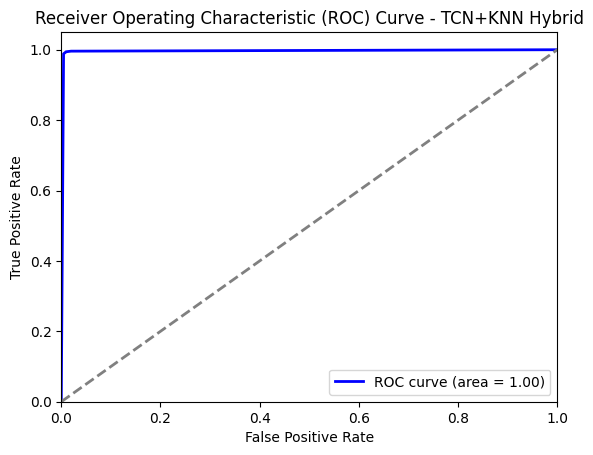

Model weights saved to 'tcn_knn_hybrid_model.weights.h5'


In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (normalize across channels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Create a TCN model for feature extraction
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# This is the feature extraction layer (before final output)
feature_extractor = Model(inputs=inputs, outputs=x)

# Compile a full TCN classifier for pre-training (to learn good features)
full_model = Model(inputs=inputs, outputs=Dense(1, activation='sigmoid')(feature_extractor.output))
full_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Pre-train the TCN (without early stopping)
history = full_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save training history (optional, for reference)
np.savez_compressed('tcn_knn_hybrid_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_knn_hybrid_training_history_main.npz'")

# Extract features using the pre-trained TCN
X_train_features = feature_extractor.predict(X_train)
X_test_features = feature_extractor.predict(X_test)

# Standardize extracted features for KNN
scaler_features = StandardScaler()
X_train_features = scaler_features.fit_transform(X_train_features)
X_test_features = scaler_features.transform(X_test_features)

# Train KNN on extracted features
knn = KNeighborsClassifier(n_neighbors=5)  # Tuned for high accuracy based on your 98% KNN result
knn.fit(X_train_features, y_train)

# Evaluate the hybrid model
y_pred_prob = knn.predict_proba(X_test_features)[:, 1]
y_pred = knn.predict(X_test_features)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+KNN Hybrid')
plt.legend(loc="lower right")
plt.show()

# Save model's weights (TCN feature extractor)
feature_extractor.save_weights('tcn_knn_hybrid_model.weights.h5')
print("Model weights saved to 'tcn_knn_hybrid_model.weights.h5'")

# **TCN+LSTM**

2026-01-29 09:33:32.651732: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769679212.854561      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769679212.916435      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769679213.410653      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769679213.410716      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769679213.410719      55 computation_placer.cc:177] computation placer alr

Epoch 1/100


I0000 00:00:1769679272.227149     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


422/422 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.5179 - loss: 0.8834 - val_accuracy: 0.4846 - val_loss: 0.7602
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.5489 - loss: 0.7836 - val_accuracy: 0.5121 - val_loss: 0.7354
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.5607 - loss: 0.7492 - val_accuracy: 0.5193 - val_loss: 0.7326
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.5618 - loss: 0.7324 - val_accuracy: 0.5113 - val_loss: 0.7132
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.5636 - loss: 0.7258 - val_accuracy: 0.5281 - val_loss: 0.6833
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.5759 - loss: 0.7092 - val_accuracy: 0.5178 - val_loss: 0.6818
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.5825 - loss: 0.7011 - val_accuracy: 0.5175 - val_loss: 0.6783
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.5858 - loss: 0.6952 - val_

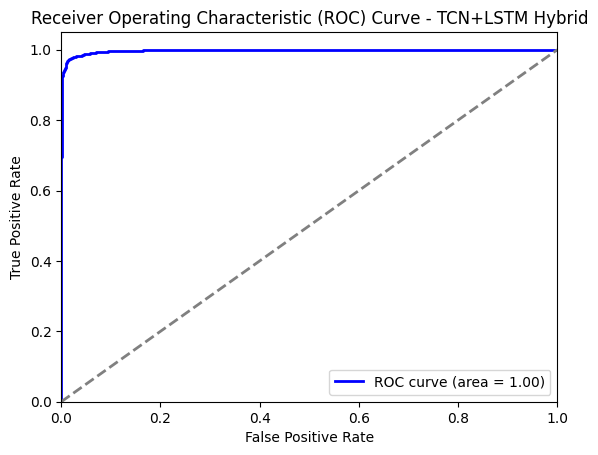

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D, LSTM
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (reshape to 2D for scaling, then back to 3D)
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

# Fit the scaler and handle zero-variance channels to prevent NaN in scaling
scaler.fit(X_train_reshaped)
scaler.scale_[scaler.scale_ == 0] = 1.0  # Set scale to 1 for zero-variance features

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

# Replace any remaining NaN/Inf with 0
X_train = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Create TCN+LSTM hybrid model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

# TCN blocks for initial temporal feature extraction
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)

# LSTM layers for capturing long-term dependencies on TCN features
x = LSTM(128, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(32, activation='tanh')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Dense layers for classification
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model with gradient clipping
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('tcn_lstm_hybrid_model_main.weights.h5')
print("Model weights saved to 'tcn_lstm_hybrid_model_main.weights.h5'")

# Save training history as .npz
np.savez_compressed('tcn_lstm_hybrid_training_history_main.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_lstm_hybrid_training_history_main.npz'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+LSTM Hybrid')
plt.legend(loc="lower right")
plt.show()

# **CNN+LSTM**

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - accuracy: 0.5245 - loss: 0.9150 - val_accuracy: 0.5900 - val_loss: 0.6762
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.5739 - loss: 0.7587 - val_accuracy: 0.6206 - val_loss: 0.6513
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.6002 - loss: 0.7145 - val_accuracy: 0.6081 - val_loss: 0.6505
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.6301 - loss: 0.6836 - val_accuracy: 0.6762 - val_loss: 0.5859
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.6403 - loss: 0.6528 - val_accuracy: 0.7041 - val_loss: 0.5567
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.6675 - loss: 0.6250 - val_accuracy: 0.7213 - val_loss: 0.5454
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.6897 - loss: 0.6006 - val_accuracy: 0.7225 - val_loss: 0.5290
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.7053 - loss: 0

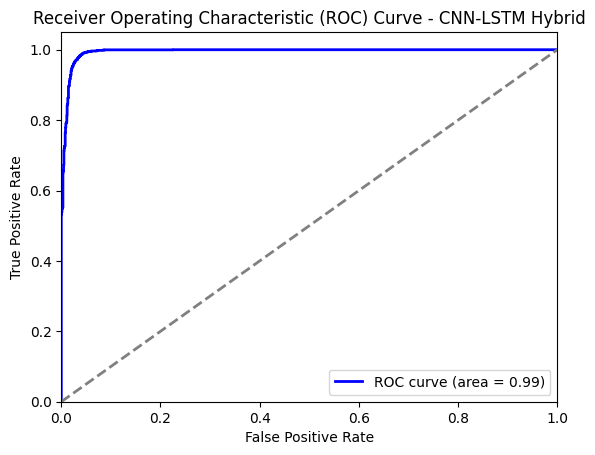

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM, Conv1D, Input
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (reshape to 2D for scaling, then back to 3D)
scaler = StandardScaler()
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])

# Fit the scaler and handle zero-variance channels to prevent NaN in scaling
scaler.fit(X_train_reshaped)
scaler.scale_[scaler.scale_ == 0] = 1.0  # Set scale to 1 for zero-variance features

X_train_scaled = scaler.transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test_reshaped).reshape(X_test.shape)

# Replace any remaining NaN/Inf with 0
X_train = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Create CNN-LSTM hybrid model (1D CNN for temporal feature extraction + LSTM for sequence modeling)
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

# 1D CNN layers for local temporal feature extraction
x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)

x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)

# LSTM layers for capturing long-term dependencies
x = LSTM(128, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(32, activation='tanh')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Dense layers for classification
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model with gradient clipping for stability
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('cnn_lstm_hybrid_model.weights.h5')
print("Model weights saved to 'cnn_lstm_hybrid_model.weights.h5'")

# Save training history as .npz
np.savez_compressed('cnn_lstm_hybrid_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'cnn_lstm_hybrid_training_history.npz'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - CNN-LSTM Hybrid')
plt.legend(loc="lower right")
plt.show()

# **2D-CNN+LSTM**

Epoch 1/50


E0000 00:00:1769697235.461483     155 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/dropout_7_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6108 - loss: 0.7431 - val_accuracy: 0.6816 - val_loss: 0.5650
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.8034 - loss: 0.4365 - val_accuracy: 0.9274 - val_loss: 0.1957
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.8948 - loss: 0.2718 - val_accuracy: 0.6052 - val_loss: 1.3633
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9383 - loss: 0.1717 - val_accuracy: 0.9357 - val_loss: 0.1557
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9502 - loss: 0.1417 - val_accuracy: 0.7802 - val_loss: 0.7733
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9669 - loss: 0.1050 - val_accuracy: 0.9209 - val_loss: 0.2558
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9766 - loss: 0.0774 - val_accuracy: 0.8318 - val_loss: 0.6555
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.9776 - loss: 0.0742 - val_accurac

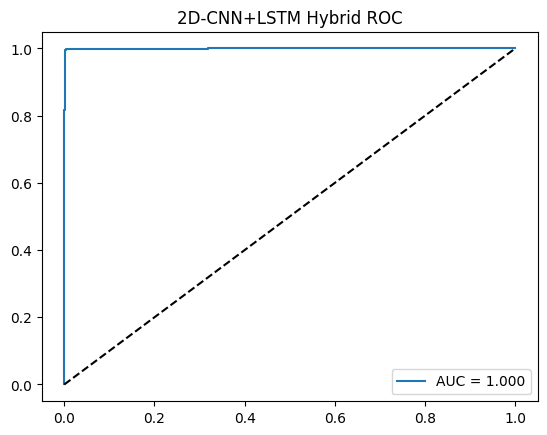

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, LSTM, Dense, Dropout, BatchNormalization, Input, Flatten, Reshape
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Reshape to 4D for 2D-CNN
X_train = X_train[..., np.newaxis]  # (samples, time, channels, 1)
X_test  = X_test[..., np.newaxis]

# Standardize (channel-wise)
scaler = StandardScaler()
X_train_resh = X_train.reshape(-1, X_train.shape[3])
X_test_resh  = X_test.reshape(-1, X_test.shape[3])
scaler.fit(X_train_resh)
scaler.scale_[scaler.scale_ == 0] = 1.0
X_train = scaler.transform(X_train_resh).reshape(X_train.shape).astype(np.float32)
X_test  = scaler.transform(X_test_resh).reshape(X_test.shape).astype(np.float32)
X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

# Build 2D-CNN + LSTM
inputs = Input(shape=(X_train.shape[1], X_train.shape[2], 1))

# Your original 2D-CNN backbone
x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)
x = Dropout(0.25)(x)

# Reshape CNN features to sequence for LSTM (time × (height*width*channels))
x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)  # (time, features)

# LSTM layers
x = LSTM(128, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, activation='tanh')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Classification head
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
              loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Save
model.save_weights('2d_cnn_lstm_hybrid_main.weights.h5')
np.savez_compressed('2d_cnn_lstm_hybrid_history_main.npz',
                    acc=history.history['accuracy'],
                    val_acc=history.history['val_accuracy'],
                    loss=history.history['loss'],
                    val_loss=history.history['val_loss'])
print("2D-CNN+LSTM hybrid saved.")

# Evaluate
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.title('2D-CNN+LSTM Hybrid ROC')
plt.legend()
plt.show()

# **TCN+FFNN**

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5625 - loss: 0.7298 - val_accuracy: 0.6448 - val_loss: 0.6583
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5996 - loss: 0.6777 - val_accuracy: 0.6448 - val_loss: 0.6594
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6117 - loss: 0.6612 - val_accuracy: 0.6448 - val_loss: 0.6498
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6190 - loss: 0.6462 - val_accuracy: 0.6448 - val_loss: 0.6412
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6110 - loss: 0.6498 - val_accuracy: 0.6448 - val_loss: 0.6311
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6150 - loss: 0.6442 - val_accuracy: 0.6448 - val_loss: 0.6347
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6247 - loss: 0.6325 - val_accuracy: 0.6448 - val_loss: 0.6302
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6211 - loss: 0.6276 - val_ac

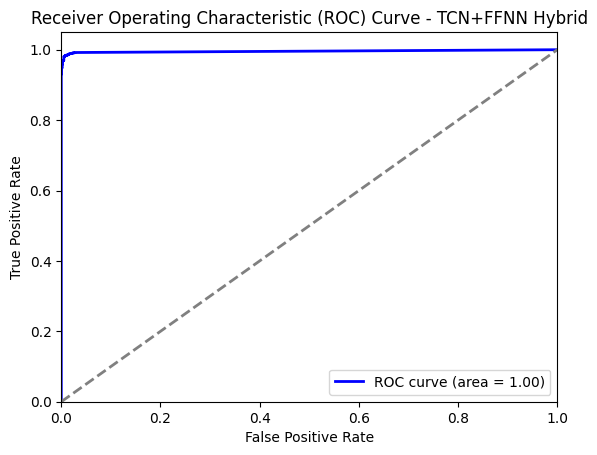

In [5]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize the features (normalize across channels, keeping 3D for TCN)
scaler = StandardScaler()
X_train_resh = X_train.reshape(-1, X_train.shape[2])
X_test_resh = X_test.reshape(-1, X_test.shape[2])
scaler.fit(X_train_resh)
scaler.scale_[scaler.scale_ == 0] = 1.0
X_train = scaler.transform(X_train_resh).reshape(X_train.shape).astype(np.float32)
X_test = scaler.transform(X_test_resh).reshape(X_test.shape).astype(np.float32)
X_train = np.nan_to_num(X_train, nan=0.0)
X_test = np.nan_to_num(X_test, nan=0.0)

# Create TCN+FFNN hybrid model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

# TCN blocks for temporal feature extraction
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)

# Flatten TCN output for FFNN
x = Flatten()(x)

# FFNN layers (from your FFNN code)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (epochs=150 to match FFNN, batch=16)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save model's weights
model.save_weights('tcn_ffnn_hybrid.weights.h5')
print("Model weights saved to 'tcn_ffnn_hybrid.weights.h5'")

# Save training history as .npz
np.savez_compressed('tcn_ffnn_hybrid_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_ffnn_hybrid_history.npz'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+FFNN Hybrid')
plt.legend(loc="lower right")
plt.show()

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5859 - loss: 0.8389 - val_accuracy: 0.6283 - val_loss: 0.6434
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6327 - loss: 0.6500 - val_accuracy: 0.6283 - val_loss: 0.6238
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6347 - loss: 0.6438 - val_accuracy: 0.6283 - val_loss: 0.6451
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6268 - loss: 0.6471 - val_accuracy: 0.6283 - val_loss: 0.6388
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6281 - loss: 0.6379 - val_accuracy: 0.6283 - val_loss: 0.6277
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6327 - loss: 0.6200 - val_accuracy: 0.6283 - val_loss: 0.6171
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6215 - loss: 0.6126 - val_accuracy: 0.6283 - val_loss: 0.6192
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6212 - loss: 0.6093 - val_ac

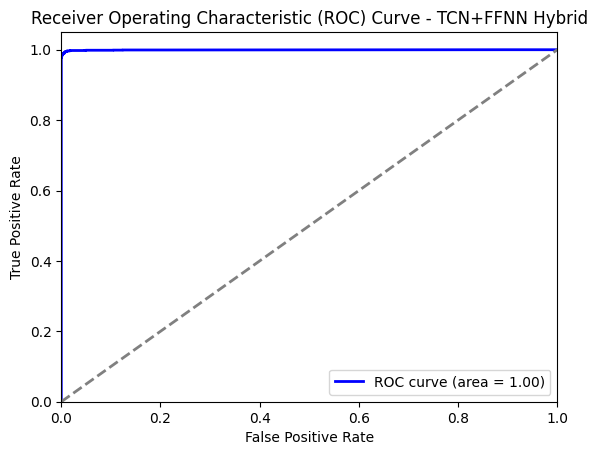

In [7]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (normalize across channels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Create TCN+FFNN hybrid model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save training history
np.savez_compressed('tcn_ffnn_hybrid_training_history_main_final.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_ffnn_hybrid_training_history_main_final.npz'")

# Save model's weights
model.save_weights('tcn_ffnn_hybrid_main_final.weights.h5')
print("Model weights saved to 'tcn_ffnn_hybrid_main_final.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+FFNN Hybrid')
plt.legend(loc="lower right")
plt.show()

# **BNN-DVI+TCN**

Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.5732 - loss: 0.9098 - val_accuracy: 0.6283 - val_loss: 0.6469
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6174 - loss: 0.6646 - val_accuracy: 0.6283 - val_loss: 0.6481
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6265 - loss: 0.6594 - val_accuracy: 0.6283 - val_loss: 0.6357
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6262 - loss: 0.6480 - val_accuracy: 0.6283 - val_loss: 0.6321
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6176 - loss: 0.6515 - val_accuracy: 0.6283 - val_loss: 0.6270
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6248 - loss: 0.6461 - val_accuracy: 0.6283 - val_loss: 0.6220
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6190 - loss: 0.6572 - val_accuracy: 0.6283 - val_loss: 0.6168
Epoch 8/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6280 - loss: 0.6284 - val_ac

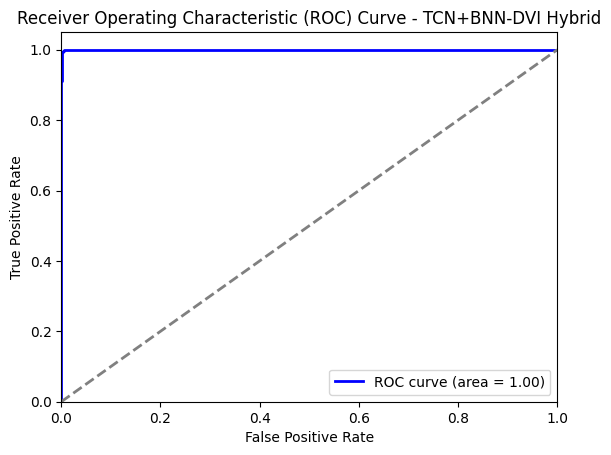

In [10]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    return x

# Load data from .npz file
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (normalize across channels)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

# Create TCN+BNN-DVI hybrid model
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)
x = Flatten()(x)

# BNN-DVI layers (from your BNN-DVI code)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout for variational approximation
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model (without early stopping)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

# Save training history
np.savez_compressed('tcn_bnn_dvi_hybrid_training_history.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_bnn_dvi_hybrid_training_history.npz'")

# Save model's weights
model.save_weights('tcn_bnn_dvi_hybrid.weights.h5')
print("Model weights saved to 'tcn_bnn_dvi_hybrid.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+BNN-DVI Hybrid')
plt.legend(loc="lower right")
plt.show()

# **ALL MODEL PLOTS**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D, Reshape)

# Config
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

# Load test data
data = np.load(DATA_PATH, allow_pickle=True)
X_test = data['X_test']
y_test = data['y_test']

time_steps = X_test.shape[1]
channels = X_test.shape[2]

# Standardize X_test (channel-wise for 3D)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_resh = X_test.reshape(-1, channels)
X_test_3d = scaler.fit_transform(X_test_resh).reshape(X_test.shape)  # Fit on test for standalone eval; use train scaler in practice
X_test_4d = X_test_3d[..., np.newaxis]  # For CNN
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Dynamic model list (add your weights and history paths here)
model_configs = [
    {'name': 'TCN+KNN', 'weights': '/kaggle/working/tcn_knn_hybrid_model.weights.h5', 'history': '/kaggle/working/tcn_knn_hybrid_training_history.npz', 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels)),
        x := Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Conv1D(64, 2, padding='causal', dilation_rate=2)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Conv1D(64, 2, padding='causal', dilation_rate=4)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Flatten()(x),
        x := Dense(128, activation='relu')(x),
        x := Dropout(0.5)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]},
    {'name': 'TCN+LSTM', 'weights': '/kaggle/working/tcn_lstm_hybrid_model_main.weights.h5', 'history': '/kaggle/working/tcn_lstm_hybrid_training_history_main.npz', 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels)),
        x := Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Conv1D(64, 2, padding='causal', dilation_rate=2)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Conv1D(64, 2, padding='causal', dilation_rate=4)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := LSTM(128, activation='tanh', return_sequences=True)(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        x := LSTM(64, activation='tanh', return_sequences=True)(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        x := LSTM(32, activation='tanh')(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        x := Dense(64, activation='relu')(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]},
    {'name': 'CNN+LSTM', 'weights': '/kaggle/working/cnn_lstm_hybrid_model.weights.h5', 'history': '/kaggle/working/cnn_lstm_hybrid_training_history.npz', 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels)),
        x := Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs),
        x := BatchNormalization()(x),
        x := Dropout(0.25)(x),
        x := Conv1D(64, kernel_size=3, activation='relu', padding='same')(x),
        x := BatchNormalization()(x),
        x := Dropout(0.25)(x),
        x := LSTM(128, activation='tanh', return_sequences=True)(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        x := LSTM(64, activation='tanh', return_sequences=True)(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        x := LSTM(32, activation='tanh')(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        x := Dense(64, activation='relu')(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]},
    {'name': '2D-CNN+LSTM', 'weights': '/kaggle/working/2d_cnn_lstm_hybrid_main.weights.h5', 'history': '/kaggle/working/2d_cnn_lstm_hybrid_history_main.npz', 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels, 1)),
        x := Conv2D(32, (3,3), activation='relu', padding='same')(inputs),
        x := MaxPooling2D((2,2))(x),
        x := Dropout(0.25)(x),
        x := Conv2D(64, (3,3), activation='relu', padding='same')(x),
        x := MaxPooling2D((2,2))(x),
        x := Dropout(0.25)(x),
        x := Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x),
        x := LSTM(128, activation='tanh', return_sequences=True)(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        x := LSTM(64, activation='tanh')(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        x := Dense(64, activation='relu')(x),
        x := BatchNormalization()(x),
        x := Dropout(0.3)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]},
    {'name': 'TCN+FFNN', 'weights': '/kaggle/working/tcn_ffnn_hybrid_main_final.weights.h5', 'history': '/kaggle/working/tcn_ffnn_hybrid_training_history_main_final.npz', 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels)),
        x := Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Conv1D(64, 2, padding='causal', dilation_rate=2)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Conv1D(64, 2, padding='causal', dilation_rate=4)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Flatten()(x),
        x := Dense(128, activation='relu')(x),
        x := Dropout(0.5)(x),
        x := Dense(64, activation='relu')(x),
        x := Dropout(0.5)(x),
        x := Dense(32, activation='relu')(x),
        x := Dropout(0.5)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]},
    {'name': 'BNN-DVI+TCN', 'weights': '/kaggle/working/tcn_bnn_dvi_hybrid.weights.h5', 'history': '/kaggle/working/tcn_bnn_dvi_hybrid_training_history.npz', 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels)),
        x := Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Conv1D(64, 2, padding='causal', dilation_rate=2)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Conv1D(64, 2, padding='causal', dilation_rate=4)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.25)(x),
        x := Flatten()(x),
        x := Dense(128, activation='relu')(x),
        x := Dropout(0.5)(x),
        x := Dense(128, activation='relu')(x),
        x := Dropout(0.5)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]}
]

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = cfg['weights']
    history_path = cfg['history']
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found")
        continue
    
    model = cfg['build_func']()
    model.load_weights(weights_path)
    
    if cfg['is_3d']:
        test_data = X_test_3d
        if 'CNN' in name:
            test_data = X_test_4d
    else:
        test_data = X_test_flat
    
    y_pred_prob = model.predict(test_data, verbose=0).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report['1']['precision']:.4f}", f"{report['1']['recall']:.4f}", f"{report['1']['f1-score']:.4f}"])
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_classification_report.png'), bbox_inches='tight')
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    for j in range(len(names), 8):
        axs[j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_confusion_matrix.png'), bbox_inches='tight')
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_roc_auc.png'), bbox_inches='tight')
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_accuracy.png'), bbox_inches='tight')
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_loss.png'), bbox_inches='tight')
    plt.close()

print("All plots generated.")

2026-01-29 17:25:48.844532: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769707549.023987      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769707549.077303      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769707549.540821      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769707549.540864      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769707549.540867      55 computation_placer.cc:177] computation placer alr

ValueError: A total of 1 objects could not be loaded. Example error message for object <Dense name=dense_1, built=True>:

Layer 'dense_1' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Dense name=dense_1, built=True>]

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D, Reshape)

# Config
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

# Load data (including train for KNN fit in TCN+KNN)
data = np.load(DATA_PATH, allow_pickle=True)
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

time_steps = X_train.shape[1]
channels =  X_train.shape[2]

# inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Standardize X_test and X_train (channel-wise for 3D)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_resh = X_train.reshape(-1, channels)
X_test_resh = X_test.reshape(-1, channels)
scaler.fit(X_train_resh)  # Fit on train
scaler.scale_[scaler.scale_ == 0] = 1.0
X_train_3d = scaler.transform(X_train_resh).reshape(X_train.shape)
X_test_3d = scaler.transform(X_test_resh).reshape(X_test.shape)
X_train_4d = X_train_3d[..., np.newaxis]
X_test_4d = X_test_3d[..., np.newaxis]
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Dynamic model list (add your weights and history paths here)
model_configs = [
    {'name': 'TCN+KNN', 'weights': '/kaggle/working/tcn_knn_hybrid_model.weights.h5', 'history': '/kaggle/working/tcn_knn_hybrid_training_history.npz', 'is_3d': True,
     'build_func': lambda: Model(
        inputs=Input(shape=(time_steps, channels)),
        outputs=Dropout(0.5)(Dense(128, activation='relu')(Flatten()(SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=4)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=2)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs))))))))))))))))},
    {'name': 'TCN+LSTM', 'weights': '/kaggle/working/tcn_lstm_hybrid_model_main.weights.h5', 'history': '/kaggle/working/tcn_lstm_hybrid_training_history_main.npz', 'is_3d': True, 
     'build_func': lambda: Model(
        inputs=Input(shape=(time_steps, channels)),
        outputs=Dense(1, activation='sigmoid')(Dropout(0.3)(BatchNormalization()(Dense(64, activation='relu')(Dropout(0.3)(BatchNormalization()(LSTM(32, activation='tanh')(
        Dropout(0.3)(BatchNormalization()(LSTM(64, activation='tanh', return_sequences=True)(
        Dropout(0.3)(BatchNormalization()(LSTM(128, activation='tanh', return_sequences=True)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=4)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=2)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs))))))))))))))))))))))))))},
    {'name': 'CNN+LSTM', 'weights': '/kaggle/working/cnn_lstm_hybrid_model.weights.h5', 'history': '/kaggle/working/cnn_lstm_hybrid_training_history.npz', 'is_3d': True, 
     'build_func': lambda: Model(
        inputs=Input(shape=(time_steps, channels)),
        outputs=Dense(1, activation='sigmoid')(Dropout(0.3)(BatchNormalization()(Dense(64, activation='relu')(Dropout(0.3)(BatchNormalization()(LSTM(32, activation='tanh')(
        Dropout(0.3)(BatchNormalization()(LSTM(64, activation='tanh', return_sequences=True)(
        Dropout(0.3)(BatchNormalization()(LSTM(128, activation='tanh', return_sequences=True)(
        Dropout(0.25)(BatchNormalization()(Conv1D(64, kernel_size=3, activation='relu', padding='same')(
        Dropout(0.25)(BatchNormalization()(Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs))))))))))))))))))))},
    {'name': '2D-CNN+LSTM', 'weights': '/kaggle/working/2d_cnn_lstm_hybrid_main.weights.h5', 'history': '/kaggle/working/2d_cnn_lstm_hybrid_history_main.npz', 'is_3d': True,
     'build_func': lambda: Model(
        inputs=Input(shape=(time_steps, channels, 1)),
        outputs=Dense(1, activation='sigmoid')(Dropout(0.3)(BatchNormalization()(Dense(64, activation='relu')(Dropout(0.3)(BatchNormalization()(LSTM(64, activation='tanh')(
        Dropout(0.3)(BatchNormalization()(LSTM(128, activation='tanh', return_sequences=True)(
        Reshape((x.shape[1], x.shape[2] * x.shape[3]))(Dropout(0.25)(MaxPooling2D((2,2))(Conv2D(64, (3,3), activation='relu', padding='same')(
        Dropout(0.25)(MaxPooling2D((2,2))(Conv2D(32, (3,3), activation='relu', padding='same')(inputs))))))))))))))))))},
    {'name': 'TCN+FFNN', 'weights': '/kaggle/working/tcn_ffnn_hybrid_main_final.weights.h5', 'history': '/kaggle/working/tcn_ffnn_hybrid_training_history_main_final.npz', 'is_3d': True, 
     'build_func': lambda: Model(
        inputs=Input(shape=(time_steps, channels)),
        outputs=Dense(1, activation='sigmoid')(Dropout(0.5)(Dense(32, activation='relu')(Dropout(0.5)(Dense(64, activation='relu')(
        Dropout(0.5)(Dense(128, activation='relu')(Flatten()(SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=4)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=2)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)))))))))))))))))))))},
    {'name': 'BNN-DVI+TCN', 'weights': '/kaggle/working/tcn_bnn_dvi_hybrid.weights.h5', 'history': '/kaggle/working/tcn_bnn_dvi_hybrid_training_history.npz', 'is_3d': True, 
     'build_func': lambda: Model(
        inputs=Input(shape=(time_steps, channels)),
        outputs=Dense(1, activation='sigmoid')(Dropout(0.5)(Dense(128, activation='relu')(Dropout(0.5)(Dense(128, activation='relu')(
        Flatten()(SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=4)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=2)(
        SpatialDropout1D(0.25)(Activation('relu')(BatchNormalization()(Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)))))))))))))))))))}
]

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = cfg['weights']
    history_path = cfg['history']
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found")
        continue
    
    model = cfg['build_func']()
    model.load_weights(weights_path)
    
    if cfg['is_3d']:
        test_data = X_test_3d
        if 'CNN' in name:
            test_data = X_test_4d
    else:
        test_data = X_test_flat
    
    y_pred_prob = model.predict(test_data, verbose=0).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report['1']['precision']:.4f}", f"{report['1']['recall']:.4f}", f"{report['1']['f1-score']:.4f}"])
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_classification_report.png'), bbox_inches='tight')
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    for j in range(len(names), 8):
        axs[j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_confusion_matrix.png'), bbox_inches='tight')
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_roc_auc.png'), bbox_inches='tight')
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_accuracy.png'), bbox_inches='tight')
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_loss.png'), bbox_inches='tight')
    plt.close()

print("All plots generated.")

NameError: name 'inputs' is not defined

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D, Reshape)

# Config
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

# Load data (including train for KNN fit in TCN+KNN)
data = np.load(DATA_PATH, allow_pickle=True)
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

time_steps = X_test.shape[1]
channels = X_test.shape[2]

# Standardize X_test and X_train (channel-wise for 3D)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_resh = X_train.reshape(-1, channels)
X_test_resh = X_test.reshape(-1, channels)
scaler.fit(X_train_resh)  # Fit on train
scaler.scale_[scaler.scale_ == 0] = 1.0
X_train_3d = scaler.transform(X_train_resh).reshape(X_train.shape)
X_test_3d = scaler.transform(X_test_resh).reshape(X_test.shape)
X_train_4d = X_train_3d[..., np.newaxis]
X_test_4d = X_test_3d[..., np.newaxis]
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Define build functions for each model
def build_tcn_knn():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    return Model(inputs=inputs, outputs=x)

def build_tcn_lstm():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_cnn_lstm():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_2d_cnn_lstm():
    inputs = Input(shape=(time_steps, channels))

    # Your original 2D-CNN backbone
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    
    # Reshape CNN features to sequence for LSTM (time × (height*width*channels))
    x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)  # (time, features)
    
    # LSTM layers
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    x = LSTM(64, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    # Classification head
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_tcn_ffnn():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_bnn_dvi_tcn():
    inputs = Input(shape=(time_steps, channels))
    x = TCN_block(inputs, filters=64, kernel_size=2, dilation_rate=1)
    x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=2)
    x = TCN_block(x, filters=64, kernel_size=2, dilation_rate=4)
    x = Flatten()(x)
    
    # BNN-DVI layers (from your BNN-DVI code)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)  # Dropout for variational approximation
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

# Dynamic model config with build_funcs as defined functions
model_configs = [
    {'name': 'TCN+KNN', 'weights': '/kaggle/working/tcn_knn_hybrid_model.weights.h5', 'history': '/kaggle/working/tcn_knn_hybrid_training_history.npz', 'is_3d': True, 'build_func': build_tcn_knn},
    {'name': 'TCN+LSTM', 'weights': '/kaggle/working/tcn_lstm_hybrid_model_main.weights.h5', 'history': '/kaggle/working/tcn_lstm_hybrid_training_history_main.npz', 'is_3d': True, 'build_func': build_tcn_lstm},
    {'name': 'CNN+LSTM', 'weights': '/kaggle/working/cnn_lstm_hybrid_model.weights.h5', 'history': '/kaggle/working/cnn_lstm_hybrid_training_history.npz', 'is_3d': True, 'build_func': build_cnn_lstm},
    {'name': '2D-CNN+LSTM', 'weights': '/kaggle/working/2d_cnn_lstm_hybrid_main.weights.h5', 'history': '/kaggle/working/2d_cnn_lstm_hybrid_history_main.npz', 'is_3d': True, 'build_func': build_2d_cnn_lstm},
    {'name': 'TCN+FFNN', 'weights': '/kaggle/working/tcn_ffnn_hybrid_main_final.weights.h5', 'history': '/kaggle/working/tcn_ffnn_hybrid_training_history_main_final.npz', 'is_3d': True, 'build_func': build_tcn_ffnn},
    {'name': 'BNN-DVI+TCN', 'weights': '/kaggle/working/tcn_bnn_dvi_hybrid.weights.h5', 'history': '/kaggle/working/tcn_bnn_dvi_hybrid_training_history.npz', 'is_3d': True, 'build_func': build_bnn_dvi_tcn}
]

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = cfg['weights']
    history_path = cfg['history']
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found")
        continue
    
    if name == 'TCN+KNN':
        # Special handling for TCN+KNN hybrid (feature extractor + KNN)
        feature_extractor = cfg['build_func']()
        feature_extractor.load_weights(weights_path)
        
        X_train_features = feature_extractor.predict(X_train_3d, verbose=0)
        X_test_features = feature_extractor.predict(X_test_3d, verbose=0)
        
        scaler_features = StandardScaler()
        X_train_features = scaler_features.fit_transform(X_train_features)
        X_test_features = scaler_features.transform(X_test_features)
        
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_features, y_train)
        
        y_pred_prob = knn.predict_proba(X_test_features)[:, 1]
        y_pred = knn.predict(X_test_features)
    else:
        # For other models (full classifiers)
        model = cfg['build_func']()
        model.load_weights(weights_path)
        
        if cfg['is_3d']:
            test_data = X_test_3d
            if 'CNN' in name:
                test_data = X_test_4d
        else:
            test_data = X_test_flat
        
        y_pred_prob = model.predict(test_data, verbose=0).ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report['1']['precision']:.4f}", f"{report['1']['recall']:.4f}", f"{report['1']['f1-score']:.4f}"])
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_classification_report.png'), bbox_inches='tight')
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    for j in range(len(names), 8):
        axs[j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_confusion_matrix.png'), bbox_inches='tight')
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_roc_auc.png'), bbox_inches='tight')
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_accuracy.png'), bbox_inches='tight')
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_loss.png'), bbox_inches='tight')
    plt.close()

print("All plots generated.")

ValueError: Input 0 of layer "conv2d_4" is incompatible with the layer: expected min_ndim=4, found ndim=3. Full shape received: (None, 250, 128)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D, Reshape)

# Config
OUTPUT_DIR = "/kaggle/working/mat-main-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "data_split.npz")

# Load data (including train for KNN fit in TCN+KNN)
data = np.load(DATA_PATH, allow_pickle=True)
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

time_steps = X_test.shape[1]
channels = X_test.shape[2]

# Standardize X_test and X_train (channel-wise for 3D)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_resh = X_train.reshape(-1, channels)
X_test_resh = X_test.reshape(-1, channels)
scaler.fit(X_train_resh)  # Fit on train
scaler.scale_[scaler.scale_ == 0] = 1.0
X_train_3d = scaler.transform(X_train_resh).reshape(X_train.shape)
X_test_3d = scaler.transform(X_test_resh).reshape(X_test.shape)
X_train_4d = X_train_3d[..., np.newaxis]
X_test_4d = X_test_3d[..., np.newaxis]
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Define build functions for each model
def build_tcn_knn():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    return Model(inputs=inputs, outputs=x)

def build_tcn_lstm():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_cnn_lstm():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.25)(x)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_2d_cnn_lstm():
    inputs = Input(shape=(time_steps, channels, 1))
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    x = Reshape((x.shape[1], x.shape[2] * x.shape[3]))(x)
    x = LSTM(128, activation='tanh', return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, activation='tanh')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_tcn_ffnn():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

def build_bnn_dvi_tcn():
    inputs = Input(shape=(time_steps, channels))
    x = Conv1D(64, 2, padding='causal', dilation_rate=1)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=2)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Conv1D(64, 2, padding='causal', dilation_rate=4)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.25)(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inputs, outputs=outputs)

# Dynamic model config with build_funcs as defined functions
model_configs = [
    {'name': 'TCN+KNN', 'weights': '/kaggle/working/tcn_knn_hybrid_model.weights.h5', 'history': '/kaggle/working/tcn_knn_hybrid_training_history.npz', 'is_3d': True, 'build_func': build_tcn_knn},
    {'name': 'TCN+LSTM', 'weights': '/kaggle/working/tcn_lstm_hybrid_model_main.weights.h5', 'history': '/kaggle/working/tcn_lstm_hybrid_training_history_main.npz', 'is_3d': True, 'build_func': build_tcn_lstm},
    {'name': 'CNN+LSTM', 'weights': '/kaggle/working/cnn_lstm_hybrid_model.weights.h5', 'history': '/kaggle/working/cnn_lstm_hybrid_training_history.npz', 'is_3d': True, 'build_func': build_cnn_lstm},
    {'name': '2D-CNN+LSTM', 'weights': '/kaggle/working/2d_cnn_lstm_hybrid_main.weights.h5', 'history': '/kaggle/working/2d_cnn_lstm_hybrid_history_main.npz', 'is_3d': True, 'build_func': build_2d_cnn_lstm},
    {'name': 'TCN+FFNN', 'weights': '/kaggle/working/tcn_ffnn_hybrid_main_final.weights.h5', 'history': '/kaggle/working/tcn_ffnn_hybrid_training_history_main_final.npz', 'is_3d': True, 'build_func': build_tcn_ffnn},
    {'name': 'BNN-DVI+TCN', 'weights': '/kaggle/working/tcn_bnn_dvi_hybrid.weights.h5', 'history': '/kaggle/working/tcn_bnn_dvi_hybrid_training_history.npz', 'is_3d': True, 'build_func': build_bnn_dvi_tcn}
]

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = cfg['weights']
    history_path = cfg['history']
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found")
        continue
    
    if name == 'TCN+KNN':
        # Special handling for TCN+KNN hybrid (feature extractor + KNN)
        feature_extractor = cfg['build_func']()
        feature_extractor.load_weights(weights_path)
        
        X_train_features = feature_extractor.predict(X_train_3d, verbose=0)
        X_test_features = feature_extractor.predict(X_test_3d, verbose=0)
        
        scaler_features = StandardScaler()
        X_train_features = scaler_features.fit_transform(X_train_features)
        X_test_features = scaler_features.transform(X_test_features)
        
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_features, y_train)
        
        y_pred_prob = knn.predict_proba(X_test_features)[:, 1]
        y_pred = knn.predict(X_test_features)
    else:
        # For other models (full classifiers)
        model = cfg['build_func']()
        model.load_weights(weights_path)
        
        if cfg['is_3d']:
            test_data = X_test_3d
            if 'CNN' in name:
                test_data = X_test_4d
        else:
            test_data = X_test_flat
        
        y_pred_prob = model.predict(test_data, verbose=0).ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report['1']['precision']:.4f}", f"{report['1']['recall']:.4f}", f"{report['1']['f1-score']:.4f}"])
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_classification_report_main.png'), bbox_inches='tight')
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    for j in range(len(names), 8):
        axs[j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_confusion_matrix_main.png'), bbox_inches='tight')
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_roc_auc_main.png'), bbox_inches='tight')
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_accuracy_main.png'), bbox_inches='tight')
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'all_train_val_loss_main.png'), bbox_inches='tight')
    plt.close()

print("All plots generated.")

2026-01-30 15:53:12.599326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769788392.948762      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769788393.049224      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769788393.888393      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769788393.888443      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769788393.888446      55 computation_placer.cc:177] computation placer alr

All plots generated.
